# Phase 4 — Feature engineering

**Objectifs**
1. Ajouter ~12 features dérivées au dataset modélisable.
2. Visualiser leur lien avec la cible NPS pour valider qu'elles apportent du signal.
3. Construire le pipeline scikit-learn `ColumnTransformer` réutilisable en Phase 6+.
4. Sauvegarder le pipeline pour usage en production (Streamlit, batch scoring).

**Principe** : qualité plutôt que quantité. Chaque feature dérivée a une justification business claire.

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import DATA_PROCESSED, FIGURES_DIR, MODELS_DIR, NPS_CLASSES, DEFAULT_TARGET
from src.features.derive import add_all_derived_features, list_derived_features
from src.features.pipeline import (
    build_preprocessing_pipeline, describe_pipeline,
    get_feature_names_after_transform, split_X_y,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")

Setup OK


## 1. Chargement & application des features dérivées

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "dataset.parquet")
print(f"Shape before: {df.shape}")

df_with = add_all_derived_features(df)
print(f"Shape after:  {df_with.shape}")
print(f"\nNew columns:")
new_cols = [c for c in df_with.columns if c not in df.columns]
for c in new_cols:
    print(f"  + {c:<25} dtype={df_with[c].dtype}")

Shape before: (7043, 42)
Shape after:  (7043, 54)

New columns:
  + n_services                dtype=int32
  + n_addons                  dtype=int32
  + has_security_bundle       dtype=int32
  + avg_monthly_charge        dtype=float64
  + charges_per_service       dtype=float64
  + tenure_bucket             dtype=object
  + is_paperless_autopay      dtype=int32
  + pop_density_bucket        dtype=object
  + has_extra_charges         dtype=int32
  + has_refund                dtype=int32
  + is_referrer               dtype=int32
  + received_offer            dtype=int32


In [4]:
# Confirm exactly the documented derived features were added
expected = list_derived_features()
actual = [c for c in df_with.columns if c not in df.columns]
print(f"Expected derivations: {len(expected)}")
print(f"Actual new columns:   {len(actual)}")
missing = set(expected) - set(actual)
unexpected = set(actual) - set(expected)
if missing:
    print(f"⚠ Missing: {missing}")
if unexpected:
    print(f"⚠ Unexpected: {unexpected}")
if not missing and not unexpected:
    print("✓ Match perfectly")

Expected derivations: 12
Actual new columns:   12
✓ Match perfectly


## 2. Validation visuelle — chaque feature apporte-t-elle du signal ?

### 2.1 `n_services` : bundle global

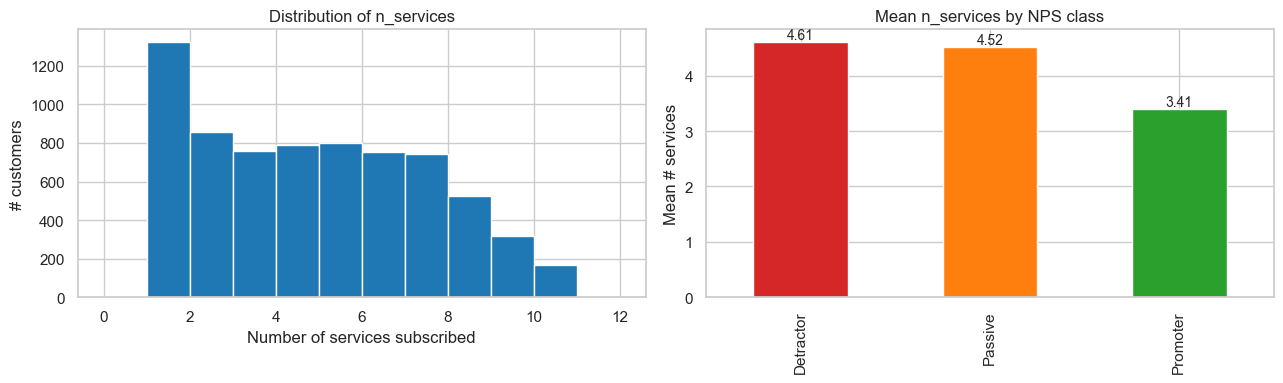

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution
axes[0].hist(df_with["n_services"], bins=range(0, 13), color="#1f77b4",
             edgecolor="white")
axes[0].set_xlabel("Number of services subscribed")
axes[0].set_ylabel("# customers")
axes[0].set_title("Distribution of n_services")

# Mean by NPS class
mean_by_nps = df_with.groupby(DEFAULT_TARGET, observed=True)["n_services"].mean().reindex(NPS_CLASSES)
mean_by_nps.plot(kind="bar", ax=axes[1], color=[NPS_PALETTE[c] for c in NPS_CLASSES])
axes[1].set_title("Mean n_services by NPS class")
axes[1].set_ylabel("Mean # services")
axes[1].set_xlabel("")
for i, v in enumerate(mean_by_nps.values):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "19_n_services.png")
plt.show()

### 2.2 `is_referrer` : signal de loyauté

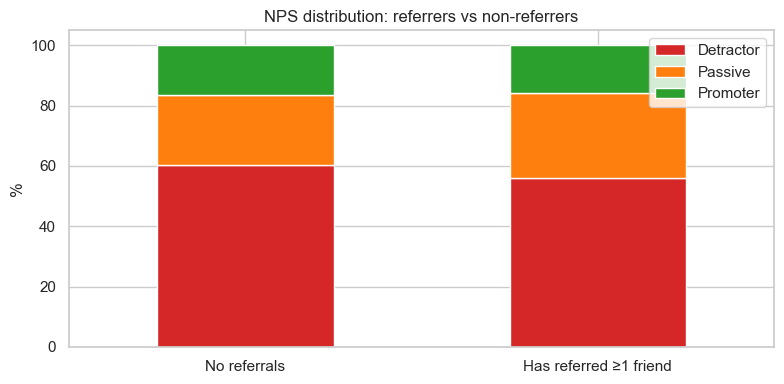

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ct = pd.crosstab(df_with["is_referrer"], df_with[DEFAULT_TARGET], normalize="index") * 100
ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
ct.index = ["No referrals", "Has referred ≥1 friend"]
ct.plot(kind="bar", stacked=True, ax=ax,
        color=[NPS_PALETTE[c] for c in NPS_CLASSES])
ax.set_title("NPS distribution: referrers vs non-referrers")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "20_is_referrer.png")
plt.show()

### 2.3 `tenure_bucket` : phases du cycle client

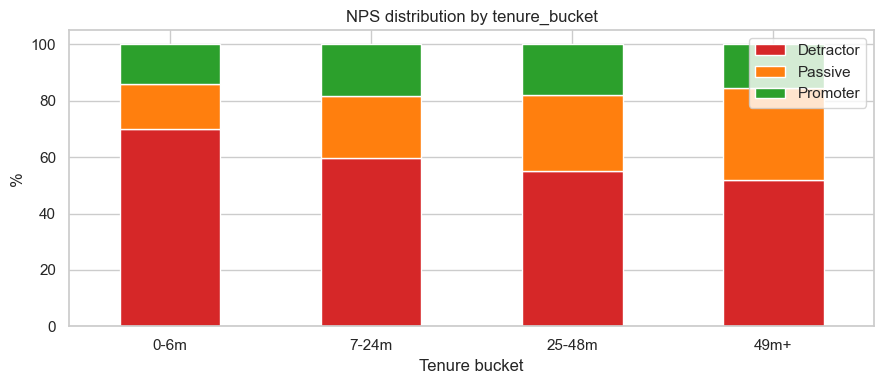

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
order = ["0-6m", "7-24m", "25-48m", "49m+"]
ct = pd.crosstab(df_with["tenure_bucket"], df_with[DEFAULT_TARGET], normalize="index") * 100
ct = ct.reindex(index=order, columns=NPS_CLASSES, fill_value=0)
ct.plot(kind="bar", stacked=True, ax=ax,
        color=[NPS_PALETTE[c] for c in NPS_CLASSES])
ax.set_title("NPS distribution by tenure_bucket")
ax.set_ylabel("%")
ax.set_xlabel("Tenure bucket")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "21_tenure_bucket.png")
plt.show()

### 2.4 `pop_density_bucket` : urbain vs rural

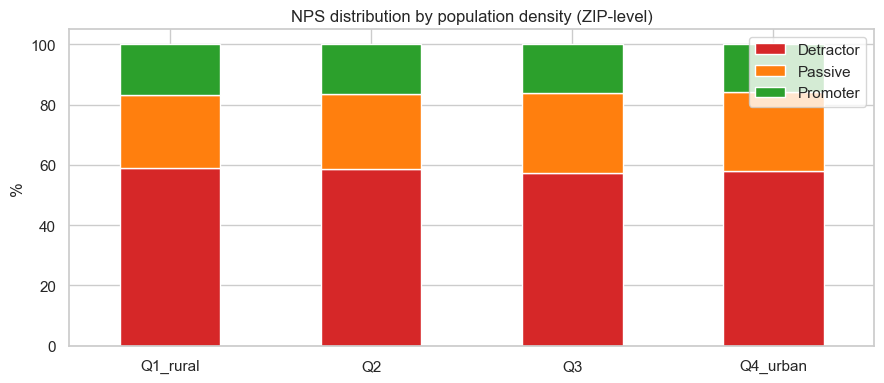

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
order = ["Q1_rural", "Q2", "Q3", "Q4_urban"]
ct = pd.crosstab(df_with["pop_density_bucket"], df_with[DEFAULT_TARGET], normalize="index") * 100
ct = ct.reindex(index=order, columns=NPS_CLASSES, fill_value=0)
ct.plot(kind="bar", stacked=True, ax=ax,
        color=[NPS_PALETTE[c] for c in NPS_CLASSES])
ax.set_title("NPS distribution by population density (ZIP-level)")
ax.set_ylabel("%")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "22_pop_density.png")
plt.show()

### 2.5 `has_extra_charges` & `has_refund` : signaux de friction

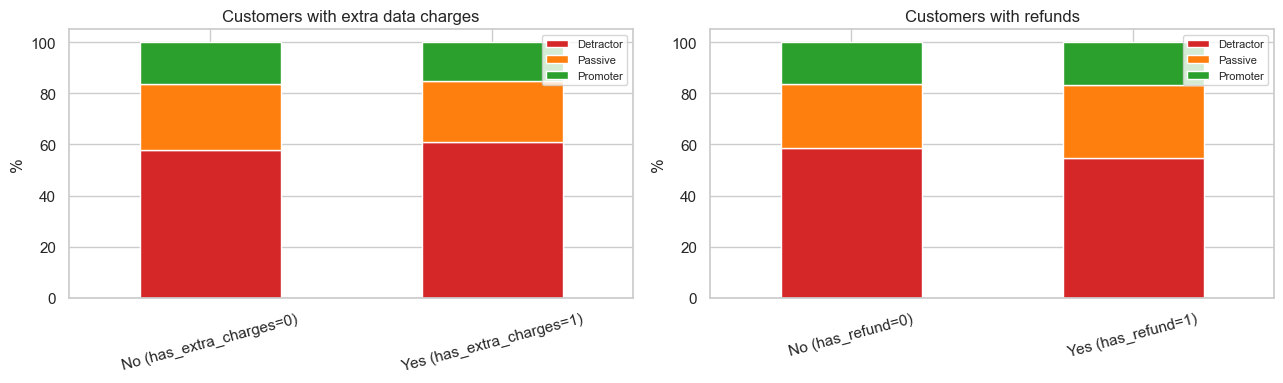

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(
    axes,
    ["has_extra_charges", "has_refund"],
    ["Customers with extra data charges", "Customers with refunds"]
):
    if col not in df_with.columns:
        ax.axis("off")
        continue
    ct = pd.crosstab(df_with[col], df_with[DEFAULT_TARGET], normalize="index") * 100
    ct = ct.reindex(columns=NPS_CLASSES, fill_value=0)
    ct.index = [f"No ({col}=0)", f"Yes ({col}=1)"]
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[NPS_PALETTE[c] for c in NPS_CLASSES])
    ax.set_title(title)
    ax.set_ylabel("%")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "23_friction_signals.png")
plt.show()

### 2.6 `avg_monthly_charge` : prix moyen historique

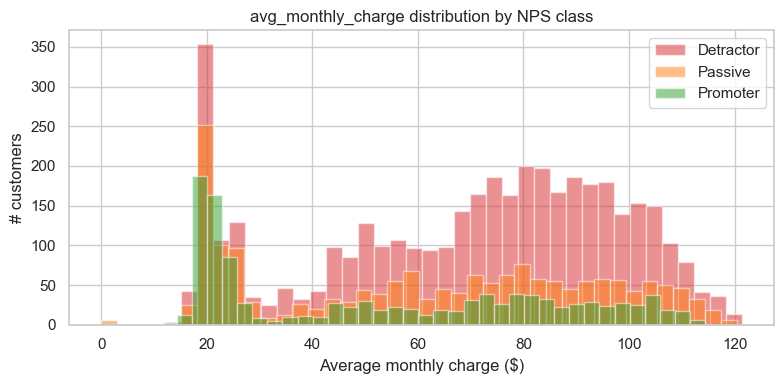

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls in NPS_CLASSES:
    sub = df_with[df_with[DEFAULT_TARGET] == cls]["avg_monthly_charge"]
    ax.hist(sub, bins=40, alpha=0.5, label=cls, color=NPS_PALETTE[cls])
ax.set_xlabel("Average monthly charge ($)")
ax.set_ylabel("# customers")
ax.set_title("avg_monthly_charge distribution by NPS class")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "24_avg_monthly_charge.png")
plt.show()

## 3. Construction du pipeline scikit-learn

In [11]:
X, y = split_X_y(df_with, target_col=DEFAULT_TARGET)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y distribution: {y.value_counts(normalize=True).round(3).to_dict()}")

X shape: (7043, 52)
y shape: (7043,)
y distribution: {'Detractor': 0.583, 'Passive': 0.254, 'Promoter': 0.163}


In [12]:
# Inspect what the pipeline will do with each column
desc = describe_pipeline(X)
print("Encoding plan per column:\n")
print(desc.to_string(index=False))

Encoding plan per column:

                           column      policy       encoding  n_unique
                             City     dropped              —      1129
                         Zip Code     dropped              —      1652
                         Latitude     dropped              —      1652
                        Longitude     dropped              —      1651
                           Gender categorical         OneHot         2
                   Senior Citizen categorical         OneHot         2
                          Partner categorical         OneHot         2
                       Dependents categorical         OneHot         2
                    Tenure Months     numeric StandardScaler        73
                    Phone Service categorical         OneHot         2
                   Multiple Lines categorical         OneHot         3
                 Internet Service categorical         OneHot         3
                  Online Security categorical     

In [13]:
# Summary by policy
print("\nSummary by encoding policy:")
print(desc.groupby(['policy', 'encoding']).size().to_frame('n_columns'))


Summary by encoding policy:
                            n_columns
policy      encoding                 
categorical OneHot                 25
dropped     —                       4
numeric     StandardScaler         23


### 3.1 Fit & transform

In [14]:
pipe = build_preprocessing_pipeline(X)
X_encoded = pipe.fit_transform(X)
print(f"X shape before:  {X.shape}")
print(f"X shape after:   {X_encoded.shape}")

# Get the output column names
feature_names = get_feature_names_after_transform(pipe, X)
print(f"\nFirst 15 output features:")
for f in feature_names[:15]:
    print(f"  {f}")
print(f"  ... ({len(feature_names) - 15} more)")

X shape before:  (7043, 52)
X shape after:   (7043, 94)

First 15 output features:
  Tenure Months
  Monthly Charges
  Total Charges
  Number of Referrals
  Avg Monthly Long Distance Charges
  Avg Monthly GB Download
  Total Refunds
  Total Extra Data Charges
  Total Long Distance Charges
  Total Revenue
  Age
  Number of Dependents
  Population
  n_services
  n_addons
  ... (79 more)


In [15]:
# Sanity: no NaN, no inf in encoded matrix
print(f"NaN in encoded matrix: {np.isnan(X_encoded).sum()}")
print(f"Inf in encoded matrix: {np.isinf(X_encoded).sum()}")
print(f"Min: {X_encoded.min():.2f}, Max: {X_encoded.max():.2f}")

NaN in encoded matrix: 0
Inf in encoded matrix: 0
Min: -2.14, Max: 8.86


## 4. Sauvegarde du pipeline

In [16]:
out_pipe = MODELS_DIR / "preprocessing_pipeline.joblib"
joblib.dump(pipe, out_pipe)
print(f"✓ Saved fitted pipeline: {out_pipe}")
print(f"   Size: {out_pipe.stat().st_size / 1024:.1f} KB")

# Save the dataset with derived features (saves recomputation in Phase 6+)
out_features = DATA_PROCESSED / "dataset_with_features.parquet"
df_with.to_parquet(out_features)
print(f"✓ Saved dataset with derived features: {out_features}")

✓ Saved fitted pipeline: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\models\preprocessing_pipeline.joblib
   Size: 10.6 KB
✓ Saved dataset with derived features: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction\data\processed\dataset_with_features.parquet


In [17]:
# Confirm round-trip works
pipe_loaded = joblib.load(out_pipe)
X_encoded_check = pipe_loaded.transform(X.head(10))
print(f"Round-trip check: pipeline transforms a 10-row sample to shape {X_encoded_check.shape}")
print("✓ Pipeline can be reloaded and reused")

Round-trip check: pipeline transforms a 10-row sample to shape (10, 94)
✓ Pipeline can be reloaded and reused


## 5. Synthèse Phase 4

### Features dérivées ajoutées (12)

| Feature | Type | Justification |
|---|---|---|
| `n_services` | int | Bundle global, proxy d'engagement |
| `n_addons` | int | Add-ons premium souscrits |
| `has_security_bundle` | binary | Top loyalty signal |
| `avg_monthly_charge` | float | Total Charges / Tenure — détecte changements |
| `charges_per_service` | float | Frustration latente si élevé |
| `tenure_bucket` | categorical | Phases du cycle client |
| `is_paperless_autopay` | binary | Engagement digital |
| `pop_density_bucket` | categorical | Urbain/rural sans ZIP |
| `has_extra_charges` | binary | Friction directe (data cap) |
| `has_refund` | binary | Service issue OU customer care |
| `is_referrer` | binary | Loyalty signal le plus fort |
| `received_offer` | binary | ROI marketing |

### Pipeline ColumnTransformer
- **Numériques** (~15 colonnes) → StandardScaler
- **Catégorielles low-cardinality** (≤ 8 levels) → OneHotEncoder
- **Catégorielles high-cardinality** (> 8 levels) → OrdinalEncoder
- **Géographiques** (`Zip Code`, `City`, `Latitude`, `Longitude`) → DROPPED
  - Population reste, encodée via `pop_density_bucket`
  - Décision conforme à la fairness (Phase 11)

### Fichiers produits
- `data/processed/dataset_with_features.parquet` — dataset enrichi
- `models/preprocessing_pipeline.joblib` — pipeline fitté, prêt pour Streamlit
- `reports/figures/19-24_*.png` — 6 figures de validation visuelle

### Prochaine étape — Phase 5 (bonus) OU Phase 6

**Option A — Phase 5 (bonus)** : générer les verbatims synthétiques avec un LLM, puis embeddings.

**Option B — Phase 6 directement** : commencer la modélisation avec le pipeline.